<a href="https://colab.research.google.com/github/AntonySSk/Machine_Learning/blob/dev/%D0%9B%D0%912_1_%D0%A8%D0%BA%D0%BE%D0%BB%D0%B0_3_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Школа, 3-9

---



# Завдання 1

Автор: Школа Антон Миколайович ФІТ 3-9

**Був присутній на парі**


Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:
import numpy as np
import pandas as pd
import requests

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_1827/1681977137.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)  # зчитати всі таблиці


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [5]:
print(f"Кількість рядків: {df.shape[0]}, Кількість стовпців: {df.shape[1]}")
df.shape

Кількість рядків: 222, Кількість стовпців: 2


(222, 2)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [34]:
# Залишаємо перші 4 стовпці з оригінальними назвами
df = df.iloc[:, [0, 1, 2, 3]]

# Якщо заголовки багаторівневі (MultiIndex), перетворюємо їх у плоскі оригінальні назви
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [f"{col[0]} {col[1]}".strip() for col in df.columns]

df.head()

,Country,IMF,World_Bank,UN
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [30]:
# 1. Заміна тире та дефісів на np.nan
df = df.replace(["—", "–", "-"], np.nan)

In [31]:
# 2. Очищення та перетворення числових стовпців (від 2-го до 4-го) у float
for col in df.columns[1:]:
    df[col] = df[col].astype(str).str.replace(',', '').str.replace(' ', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [32]:
# 3. Перевірка наявності пропущених значень
print("Кількість пропущених значень у кожному стовпці:")
print(df.isna().sum())

Кількість пропущених значень у кожному стовпці:
Country       0
IMF           0
World_Bank    0
UN            0
dtype: int64


In [33]:
# 4. Заміна пропущених значень (NaN) на середнє значення відповідного стовпця
for col in df.columns[1:]:
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)

5. Ще раз вивести датасет

In [35]:
df

,Country,IMF,World_Bank,UN
0,World,1.262953e+08,1.183502e+08,111565144.0
1,United States,3.238392e+07,3.076970e+07,29298000.0
2,China[n 1],2.085159e+07,1.949804e+07,18743802.0
3,Germany,5.452858e+06,5.050923e+06,4659929.0
4,Japan,4.379253e+06,4.435163e+06,4026211.0
...,...,...,...,...
217,Palau,3.770000e+02,3.450000e+02,310.0
218,Marshall Islands,3.420000e+02,3.080000e+02,281.0
219,Nauru,1.960000e+02,1.760000e+02,187.0
220,Montserrat,1.319229e+06,1.255590e+06,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [38]:
print(f"Кількість дублікатів: {df.duplicated().sum()}")
df = df.drop_duplicates()

Кількість дублікатів: 0


In [52]:
df = df.drop_duplicates()

7.	Вивести описову статистику датасету describe()

In [39]:
df.describe()

,IMF,World_Bank,UN
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.319229e+06,1.255590e+06,1.043818e+06
std,8.838876e+06,8.288461e+06,7.830341e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.932375e+04,2.003400e+04,9.170750e+03
50%,1.039745e+05,9.986350e+04,4.322450e+04
75%,7.726678e+05,1.041520e+06,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [40]:
# Беремо другий (IMF) та третій (World Bank) стовпці за їхніми позиціями
imf_col = df.columns[1]
wb_col = df.columns[2]

# Обчислення абсолютної різниці (відхилення)
df['GDP_Diff'] = (df[imf_col] - df[wb_col]).abs()

# Сортування за спаданням для знаходження країн з найбільшою різницею
top_diff = df.sort_values(by='GDP_Diff', ascending=False)

print("Топ-5 країн з найбільшим відхиленням:")
top_diff[[df.columns[0], imf_col, wb_col, 'GDP_Diff']].head()

Топ-5 країн з найбільшим відхиленням:


,Country,IMF,World_Bank,GDP_Diff
0,World,1.262953e+08,118350166.0,7.945165e+06
1,United States,3.238392e+07,30769700.0,1.614220e+06
2,China[n 1],2.085159e+07,19498039.0,1.353554e+06
197,Sint Maarten,1.319229e+06,1888.0,1.317341e+06
146,Palestine[n 11][n 12],1.319229e+06,17167.0,1.302062e+06


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [47]:
# Обчислення матриці кореляції між трьома числовими стовпцями з ВВП
corr_matrix = df.iloc[:, [1, 2, 3]].corr()

In [48]:
print("Матриця кореляцій:")
corr_matrix

Матриця кореляцій:


,IMF,World_Bank,UN
IMF,1.000000,0.999497,0.998998
World_Bank,0.999497,1.000000,0.998864
UN,0.998998,0.998864,1.000000


10. Обчислити середнє значення за стовпцями

In [49]:
# Обчислення середнього значення для всіх числових стовпців датасета
df.iloc[:, 1:4].mean()

,0
IMF,1.319229e+06
World_Bank,1.255590e+06
UN,1.043818e+06


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [50]:
# 1. Обчислюємо стандартне відхилення за рядками (axis=1) для числових стовпців з ВВП
df['STD_GDP'] = df.iloc[:, 1:4].std(axis=1)

# 2. Знаходимо країну з найвищою варіативністю (максимальним стандартним відхиленням)
max_var_country = df.sort_values(by='STD_GDP', ascending=False)

print("Країни з найвищою варіативністю показників ВВП між роками/організаціями:")
max_var_country[[df.columns[0], 'STD_GDP']].head()

Країни з найвищою варіативністю показників ВВП між роками/організаціями:


,Country,STD_GDP
0,World,7.372704e+06
1,United States,1.543508e+06
2,China[n 1],1.068002e+06
197,Sint Maarten,7.606303e+05
146,Palestine[n 11][n 12],7.520782e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [53]:
country_col = df.columns[0]  # Назва стовпця з країнами

# Проходимо по трьох числових стовпцях ВВП (IMF, World Bank, UN)
for col in df.columns[1:4]:
    max_idx = df[col].idxmax()
    min_idx = df[col].idxmin()

    max_country = df.loc[max_idx, country_col]
    max_value = df.loc[max_idx, col]

    min_country = df.loc[min_idx, country_col]
    min_value = df.loc[min_idx, col]

    print(f"--- {col} ---")
    print(f"Найвищий ВВП: {max_country} ({max_value})")
    print(f"Найнижчий ВВП: {min_country} ({min_value})\n")

--- IMF ---
Найвищий ВВП: World (126295331.0)
Найнижчий ВВП: Tuvalu (65.0)

--- World_Bank ---
Найвищий ВВП: World (118350166.0)
Найнижчий ВВП: Tuvalu (57.0)

--- UN ---
Найвищий ВВП: World (111565144.0)
Найнижчий ВВП: Tuvalu (56.0)



13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

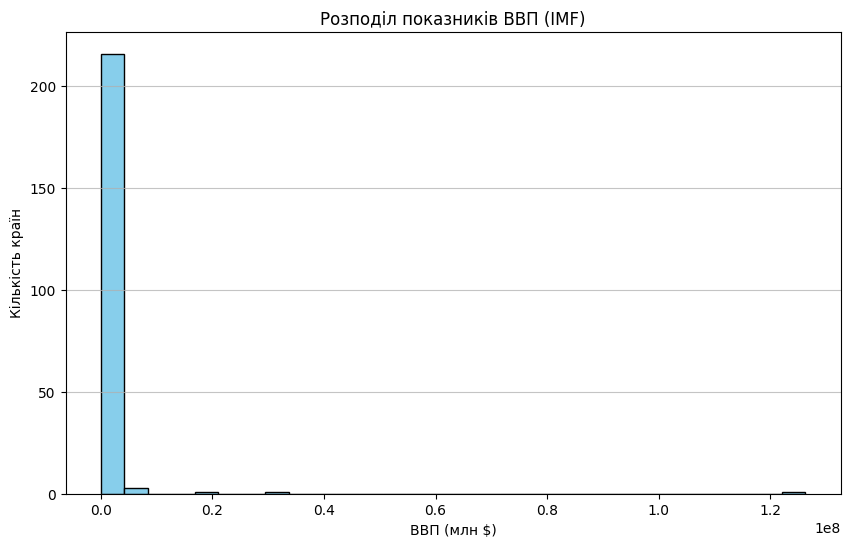

In [54]:
import matplotlib.pyplot as plt

# Беремо стовпець показників IMF (2-й стовпець)
imf_col = df.columns[1]

# Побудова гістограми
plt.figure(figsize=(10, 6))
plt.hist(df[imf_col], bins=30, edgecolor='black', color='skyblue')
plt.title('Розподіл показників ВВП (IMF)')
plt.xlabel('ВВП (млн $)')
plt.ylabel('Кількість країн')
plt.grid(axis='y', alpha=0.75)
plt.show()

Який вигляд має розподіл?

Майже всі дані зосереджені в одному високому стовпчику на початку (зліва). Це свідчить про те, що переважна більшість країн має порівняно невеликі значення ВВП.

Чи є країни, що виділяються?

Так, на графіку чітко видно кілька поодиноких низьких стовпчиків, віддалених праворуч (особливо біля позначок 0.2, 0.3 та понад 1.2). Це окремі країни з надзвичайно великим ВВП, які сильно відриваються від загальної маси.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [55]:
# Розрахунок частки (у відсотках) кожної країни від загальної суми за кожен рік/організацію
df['Share_IMF'] = (df.iloc[:, 1] / df.iloc[:, 1].sum()) * 100
df['Share_WB'] = (df.iloc[:, 2] / df.iloc[:, 2].sum()) * 100
df['Share_UN'] = (df.iloc[:, 3] / df.iloc[:, 3].sum()) * 100

# Виведення перших 5 рядків з частками
df[[df.columns[0], 'Share_UN', 'Share_WB', 'Share_IMF']].head()

,Country,Share_UN,Share_WB,Share_IMF
0,World,48.144944,42.458818,43.123505
1,United States,12.643291,11.038811,11.057480
2,China[n 1],8.088721,6.995036,7.119770
3,Germany,2.010951,1.812048,1.861877
4,Japan,1.737475,1.591141,1.495295


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

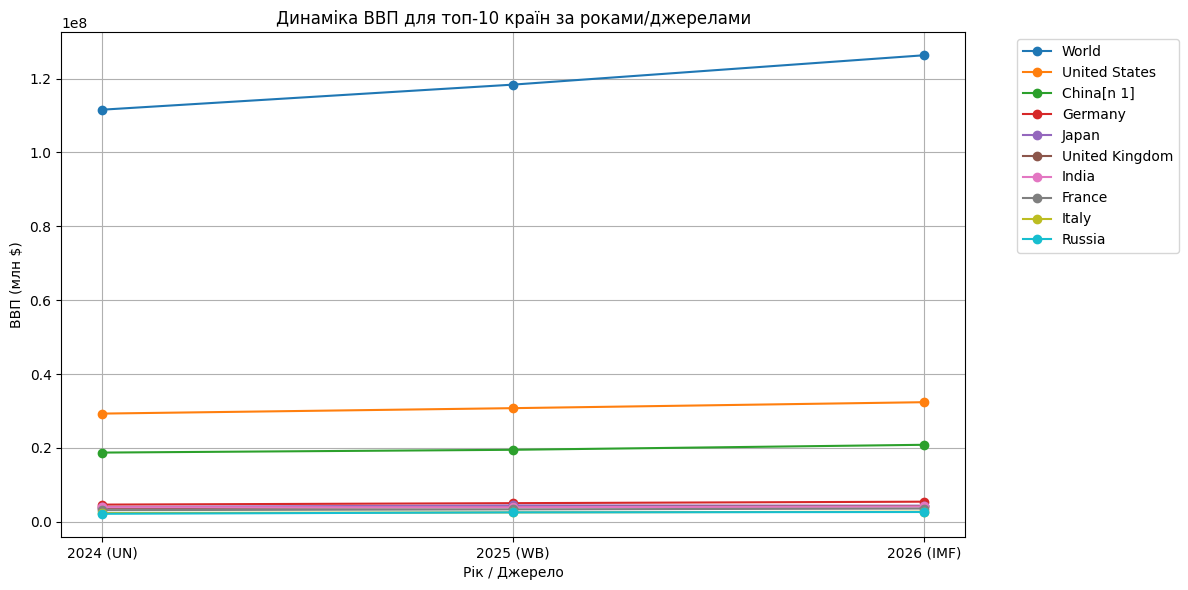

In [56]:
import matplotlib.pyplot as plt

# Вибираємо топ-10 країн за показником ВВП
top10 = df.head(10)

# Беремо назву країни та три роки (UN 2024, World Bank 2025, IMF 2026)
country_col = df.columns[0]
years = ['2024 (UN)', '2025 (WB)', '2026 (IMF)']

plt.figure(figsize=(12, 6))

# Будуємо лінію для кожної країни з топ-10
for _, row in top10.iterrows():
    values = [row.iloc[3], row.iloc[2], row.iloc[1]]  # UN -> WB -> IMF
    plt.plot(years, values, marker='o', label=row[country_col])

plt.title('Динаміка ВВП для топ-10 країн за роками/джерелами')
plt.xlabel('Рік / Джерело')
plt.ylabel('ВВП (млн $)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

14.Як змінюються частки країн з часом?   

Стабільність основних лідерів: Частки найбільших економік світу залишаються стабільно високими та змінюються лише на незначні частки відсотка від року до року.

Основна маса країн: Частки більшості малих та середніх країн залишаються майже незмінними і складають лише дрібні долі відсотка від світового ВВП.

15.Які країни показують стабільне зростання?   

Світ у цілому (World), США (United States) та Китай (China): На графіку чітко видно, що лінії World, United States та China стабільно йдуть вгору від 2024 до 2026 року, що демонструє постійне зростання їхніх показників ВВП.   

Які країни показують стабільність або незначні зміни?   

Інші країни з топ-10 (Німеччина, Японія, Велика Британія, Індія, Франція, Італія, Росія): Їхні лінії розташовані знизу майже паралельно горизонтальній осі. Це показує, що їхні показники ВВП залишаються стабільними з незначними змінами між роками та джерелами.